# Gene-set expression across cortical neuropil spots (SECOND AD-WT MERSCOPE pair)

Self-contained notebook. Visualizes the spatial expression pattern of three gene sets from `data/gene_panel_v2.xlsx` (sheet `Panel_v2`) across the neuropil spots of the **Isocortex** for the second WT/AD sample pair:

1. **`pathway_p1`** — `Pathway gene`s with `Priority == 1`
2. **`pathway_p2`** — `Pathway gene`s with `Priority == 2`
3. **`AD_genes`** — all genes in the `AD gene` category

Pipeline:
1. Read each gene set from `Panel_v2` and parse each gene's predicted AD direction (up / down) from the `Subcategory` text.
2. Load + concatenate the two granule adata (`output/MERSCOPE_AD_2`, `output/MERSCOPE_WT_2`); keep only granules in the `Isocortex`. **No subdomain stratification** — all cortical spots are used.
3. Grid each sample independently (50×50 µm spots) and aggregate the raw granule counts of the granules inside each spot (`spot_embedding` → `spot_granule_expression`, no smoothing).
4. Put both samples on one canvas: keep WT as-is (left), **flip AD horizontally then vertically** and place it to the **right**.
5. Per gene: spatial scatter of **log2(aggregated granule counts + 1)** with a `magma` colorbar. Each set goes to its own folder; genes predicted up/down in AD get `_up` / `_down` appended to the file name.
6. Per set: a grouped (split) violin plot of the per-spot log2 counts, WT vs AD.

Use the `mcDETECT-env` kernel.

In [1]:
import os
import re

import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy.sparse import csr_matrix

from mcDETECT.downstream import spot_embedding

import warnings
warnings.filterwarnings("ignore")
sc.settings.verbosity = 0

/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-p

## Config

In [2]:
# Repo root (this notebook lives in code/)
BASE = os.path.abspath("..")

AD_PATH = os.path.join(BASE, "output/MERSCOPE_AD_2/granule_adata_raw.h5ad")
WT_PATH = os.path.join(BASE, "output/MERSCOPE_WT_2/granule_adata_raw.h5ad")
GENE_PANEL_PATH = os.path.join(BASE, "data/gene_panel_v2.xlsx")

ROI = "Isocortex"      # cortical area; all spots used (no subdomain stratification)
GRID_LEN = 50          # spot size in microns (50 x 50)

CMAP = "magma"         # colorbar for expression
DOT_SIZE = 15          # dot size for the scatter
VMAX_PCT = 99          # clip the colorbar at this per-gene percentile (robust to outliers)
GAP_FRAC = 0.05        # horizontal gap between WT and AD (fraction of WT width)

# Gene sets to visualize: (set_key, panel Category, Priority filter or None, display label)
GENE_SET_SPECS = [
    ("pathway_p1", "Pathway gene", 1, "Priority-1 pathway genes"),
    ("pathway_p2", "Pathway gene", 2, "Priority-2 pathway genes"),
    ("AD_genes", "AD gene", None, "AD genes"),
]
SET_LABELS = {key: label for key, _, _, label in GENE_SET_SPECS}

# One output folder per gene set.
OUTPUT_BASE = os.path.join(BASE, "output/MERSCOPE_WT_AD_2_comparison/")
OUTPUT_PATHS = {
    key: os.path.join(OUTPUT_BASE, f"{key}_expression_{ROI}_{GRID_LEN}/")
    for key, _, _, _ in GENE_SET_SPECS
}
for key, path in OUTPUT_PATHS.items():
    os.makedirs(path, exist_ok=True)
    print(f"{key}: {path}")

pathway_p1: /Users/chenyang/Desktop/mcDETECT/output/MERSCOPE_WT_AD_2_comparison/pathway_p1_expression_Isocortex_50/
pathway_p2: /Users/chenyang/Desktop/mcDETECT/output/MERSCOPE_WT_AD_2_comparison/pathway_p2_expression_Isocortex_50/
AD_genes: /Users/chenyang/Desktop/mcDETECT/output/MERSCOPE_WT_AD_2_comparison/AD_genes_expression_Isocortex_50/


## Helper: occupied-cell spot grid

One spot per 50×50 tile that contains ≥1 granule. The tile centroid matches `spot_embedding`'s half-open containment box exactly (same construction as `code/8_neuropil_subdomains_pair2.ipynb`).

In [3]:
def build_spot_grid(obs, grid_len, x_col="global_x", y_col="global_y"):
    gx = obs[x_col].to_numpy(dtype=float)
    gy = obs[y_col].to_numpy(dtype=float)
    ix = np.floor(gx / grid_len).astype(int)
    iy = np.floor(gy / grid_len).astype(int)
    cells = np.unique(np.stack([ix, iy], axis=1), axis=0)
    cx = (cells[:, 0] + 0.5) * grid_len
    cy = (cells[:, 1] + 0.5) * grid_len
    spots = anndata.AnnData(X=np.zeros((len(cx), 1), dtype=np.float32))
    spots.obs["global_x"] = cx
    spots.obs["global_y"] = cy
    spots.obs["spot_id"] = [f"spot_{i}" for i in range(len(cx))]
    return spots

## 1. Gene sets + predicted AD direction

The predicted AD direction is parsed from the `Subcategory` text: an isolated `up` → up-in-AD, an isolated `down` → down-in-AD, otherwise no direction (e.g. `Glutamate receptor (NMDA)`, `APP processing`, `AD risk`).

In [4]:
def parse_ad_direction(subcategory):
    s = str(subcategory).lower()
    has_up = bool(re.search(r"\bup\b", s))
    has_down = bool(re.search(r"\bdown\b", s))
    if has_up and not has_down:
        return "up"
    if has_down and not has_up:
        return "down"
    return ""


panel = pd.read_excel(GENE_PANEL_PATH, sheet_name="Panel_v2")

set_rows = []
for key, category, priority, _ in GENE_SET_SPECS:
    sel = panel[panel["Category"] == category]
    if priority is not None:
        sel = sel[sel["Priority"] == priority]
    sel = sel.copy()
    sel["set_key"] = key
    set_rows.append(sel)

sel_all = pd.concat(set_rows, ignore_index=True)
sel_all["Gene"] = sel_all["Gene"].astype(str)
sel_all["direction"] = sel_all["Subcategory"].map(parse_ad_direction)
gene_direction = dict(zip(sel_all["Gene"], sel_all["direction"]))

genes_listed_by_set = {
    key: sel_all.loc[sel_all["set_key"] == key, "Gene"].tolist()
    for key, _, _, _ in GENE_SET_SPECS
}
for key, _, _, label in GENE_SET_SPECS:
    sub = sel_all[sel_all["set_key"] == key]
    print(f"{label} ({key}): {sub.shape[0]} genes "
          f"(up={int((sub['direction'] == 'up').sum())}, "
          f"down={int((sub['direction'] == 'down').sum())}, "
          f"none={int((sub['direction'] == '').sum())})")

Priority-1 pathway genes (pathway_p1): 17 genes (up=6, down=4, none=7)
Priority-2 pathway genes (pathway_p2): 63 genes (up=17, down=17, none=29)
AD genes (AD_genes): 38 genes (up=25, down=1, none=12)


## 2. Load + concatenate the two granule adata (Isocortex only)

In [5]:
ad = sc.read_h5ad(AD_PATH)
wt = sc.read_h5ad(WT_PATH)
ad.obs["sample"] = "AD"
wt.obs["sample"] = "WT"

# Same 290-gene panel; concat on shared genes. index_unique avoids obs_name collisions.
granule = anndata.concat([wt, ad], join="inner", index_unique="-")
granule.obs["sample"] = granule.obs["sample"].astype(str)

# Preserve raw counts for spot-level expression aggregation.
granule.layers["counts"] = csr_matrix(granule.X.copy())

# Restrict to the cortical area; no subdomain stratification.
granule = granule[granule.obs["brain_area"] == ROI].copy()

# spot_embedding needs a subtype key; we aggregate ALL granules, so use one dummy subtype.
granule.obs["all_granules"] = "all"

print(f"{ROI} granules: {granule.shape}")
print(granule.obs["sample"].value_counts())

# Which genes of each set are actually measured on this 290-gene panel.
genes_by_set = {}
for key, _, _, label in GENE_SET_SPECS:
    listed = genes_listed_by_set[key]
    present = [g for g in listed if g in granule.var_names]
    missing = [g for g in listed if g not in granule.var_names]
    genes_by_set[key] = present
    print(f"\n{label} present on panel ({len(present)}): {present}")
    print(f"{label} NOT on this 290-gene panel ({len(missing)}): {missing}")

# Union of all genes to aggregate once.
all_genes = sorted(set(g for gs in genes_by_set.values() for g in gs))

Isocortex granules: (378378, 290)
sample
WT    195304
AD    183074
Name: count, dtype: int64

Priority-1 pathway genes present on panel (4): ['Grin1', 'Grin2b', 'Arc', 'Kalrn']
Priority-1 pathway genes NOT on this 290-gene panel (13): ['Calm1', 'Ppp3ca', 'Picalm', 'Grin2a', 'Grm5', 'Ndufab1', 'Cplx1', 'Dnm1', 'Rab3a', 'Cdc42', 'Cfl1', 'Dpysl2', 'Rac1']

Priority-2 pathway genes present on panel (13): ['Epha4', 'Cacna1a', 'Itpr1', 'Camk2b', 'Itgam', 'Kif5a', 'Cyfip1', 'Dlg2', 'Dlgap4', 'Epb41l1', 'Ppp1r9b', 'Sipa1l1', 'Pacsin1']
Priority-2 pathway genes NOT on this 290-gene panel (50): ['Egr1', 'Fos', 'Npas4', 'Lamp1', 'Map1lc3b', 'Sqstm1', 'Tfeb', 'Nrp1', 'Robo2', 'Cacna1c', 'Cacna1e', 'Atp2b1', 'Ryr2', 'Calm2', 'Ppp3r1', 'Cd47', 'Gria3', 'Gria4', 'Grik2', 'Grm1', 'Grm3', 'Ppargc1a', 'Tfam', 'Atp5f1b', 'Cox5a', 'Cox6c', 'Ndufa4', 'Sdhb', 'Uqcrc2', 'Il33', 'Creb1', 'Amph', 'Cadps', 'Napa', 'Nsf', 'Rims2', 'Synj1', 'Syt7', 'Unc13a', 'Actr3', 'Arhgef7', 'Arpc2', 'Cttn', 'Limk1', 'Map1b', 

## 3. Grid each sample and aggregate granule expression per spot

Each sample is gridded in its own coordinate frame (coordinates are not aligned across samples). `spot_granule_expression` sums the raw counts of the granules inside each 50×50 spot (`smoothing=False`).

In [6]:
gene_idx = [granule.var_names.get_loc(g) for g in all_genes]

expr_frames = {}
for s in ["WT", "AD"]:
    g_s = granule[granule.obs["sample"] == s].copy()
    spots_s = build_spot_grid(g_s.obs, GRID_LEN)

    _, _, aux, spot_expr, _ = spot_embedding(
        spots=spots_s,
        granule_adata=g_s,
        adata=None,
        count_matrix=None,
        spot_loc_key=("global_x", "global_y"),
        spot_width=GRID_LEN,
        spot_height=GRID_LEN,
        granule_loc_key=("global_x", "global_y"),
        granule_subtype_key="all_granules",
        subtype_names=["all"],
        granule_count_layer="counts",
        include_soma_features=False,
        smoothing=False,
    )

    keep = aux["granule_count"] > 0
    df = spots_s.obs.loc[keep, ["global_x", "global_y"]].copy()
    df["sample"] = s
    df["granule_count"] = aux["granule_count"][keep]
    expr_keep = spot_expr[keep][:, gene_idx]
    for j, g in enumerate(all_genes):
        df[g] = expr_keep[:, j]
    expr_frames[s] = df.reset_index(drop=True)
    print(f"[{s}] spots with granules: {int(keep.sum())}")

wt_df = expr_frames["WT"]
ad_df = expr_frames["AD"]

[WT] spots with granules: 2146


[AD] spots with granules: 2071


## 4. Combine samples on one canvas

Keep WT in its own frame (left). Flip AD **horizontally then vertically** (a 180° reflection within its own bounding box), then translate it to the **right** of WT (bottoms aligned).

In [7]:
wt_plot = wt_df.copy()
ad_plot = ad_df.copy()

# Flip AD horizontally then vertically within its own bounding box.
ad_plot["global_x"] = (ad_df["global_x"].min() + ad_df["global_x"].max()) - ad_df["global_x"]
ad_plot["global_y"] = (ad_df["global_y"].min() + ad_df["global_y"].max()) - ad_df["global_y"]

# Place the flipped AD to the right of WT; align the bottom (min y).
gap = GAP_FRAC * (wt_plot["global_x"].max() - wt_plot["global_x"].min())
x_shift = wt_plot["global_x"].max() + gap - ad_plot["global_x"].min()
y_shift = wt_plot["global_y"].min() - ad_plot["global_y"].min()
ad_plot["global_x"] = ad_plot["global_x"] + x_shift
ad_plot["global_y"] = ad_plot["global_y"] + y_shift

combined = pd.concat([wt_plot, ad_plot], ignore_index=True)

# Sample label anchor positions (top of the canvas). WT is on the left, AD on the right.
y_top = combined["global_y"].max()
wt_cx = wt_plot["global_x"].mean()
ad_cx = ad_plot["global_x"].mean()
print(combined.groupby("sample").size())

sample
AD    2071
WT    2146
dtype: int64


## 5. Visualize per-gene expression (WT | AD, magma)

Color = **log2(aggregated granule counts + 1)** of the per-spot expression (the sum of granule mRNA counts within each spot). Each gene set goes to its own folder; genes predicted up/down in AD get `_up` / `_down` appended to the file name.


=== Priority-1 pathway genes (pathway_p1) -> /Users/chenyang/Desktop/mcDETECT/output/MERSCOPE_WT_AD_2_comparison/pathway_p1_expression_Isocortex_50/ ===


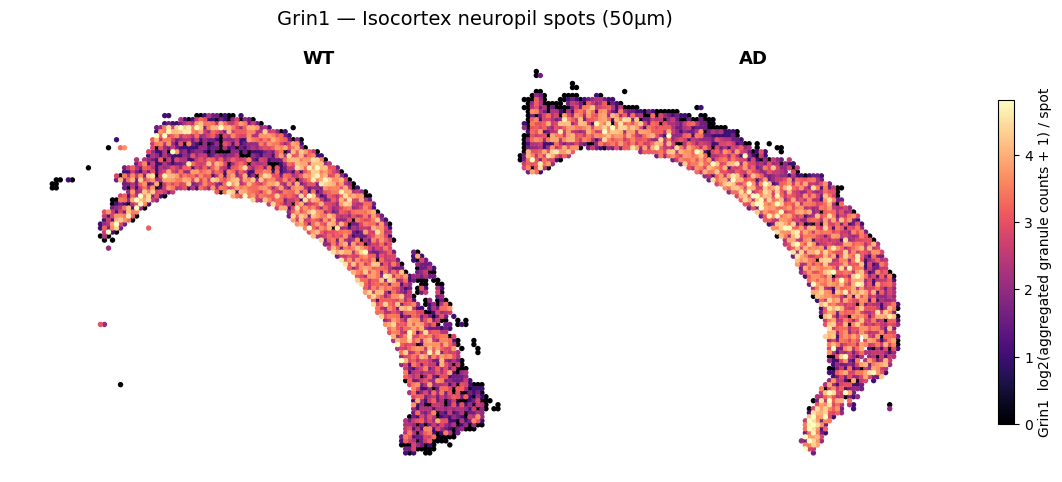

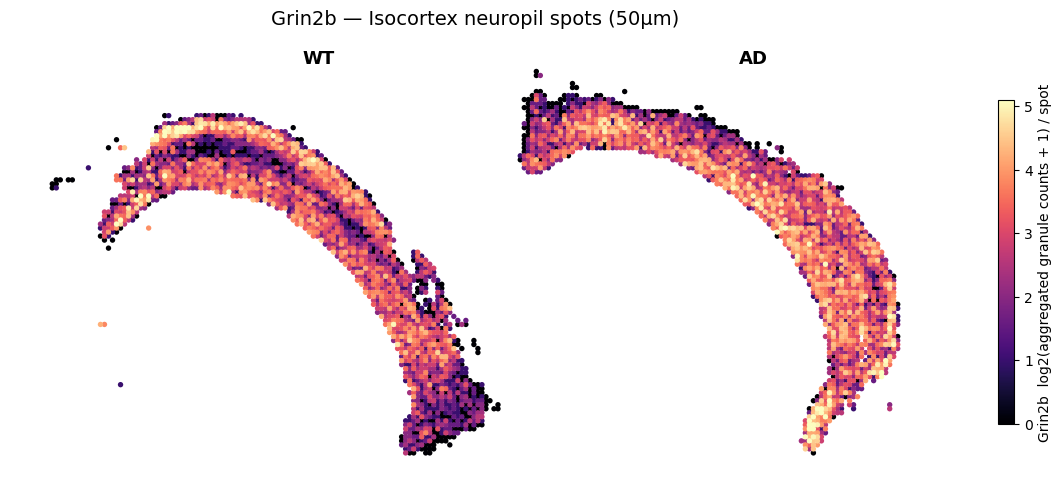

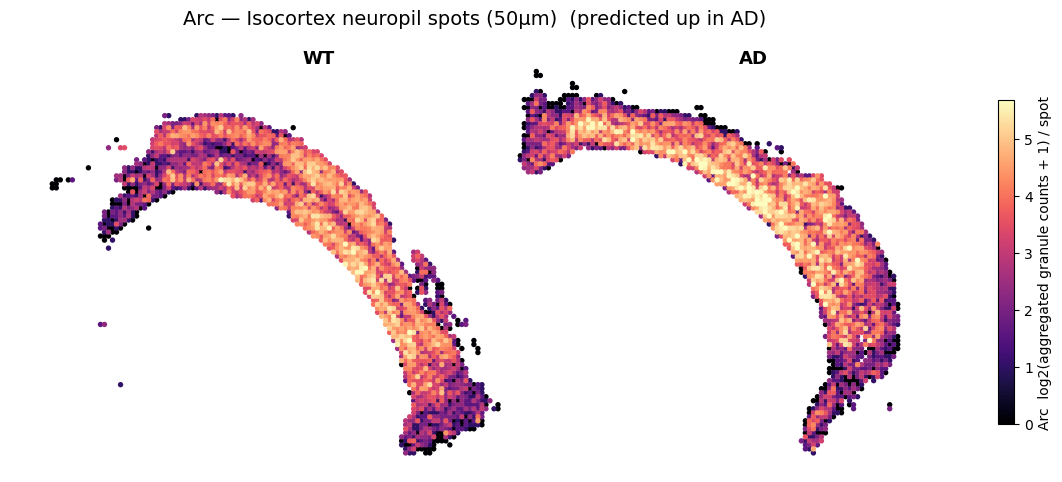

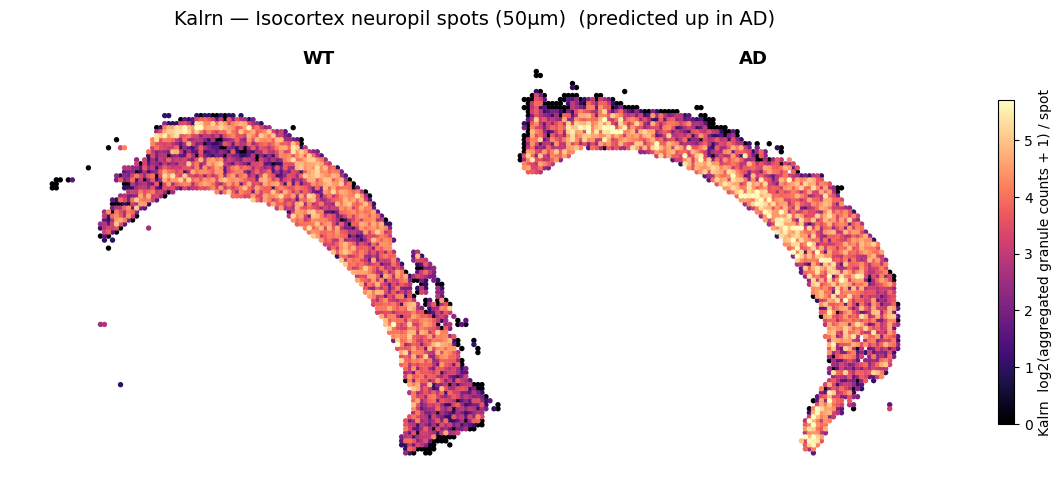


=== Priority-2 pathway genes (pathway_p2) -> /Users/chenyang/Desktop/mcDETECT/output/MERSCOPE_WT_AD_2_comparison/pathway_p2_expression_Isocortex_50/ ===


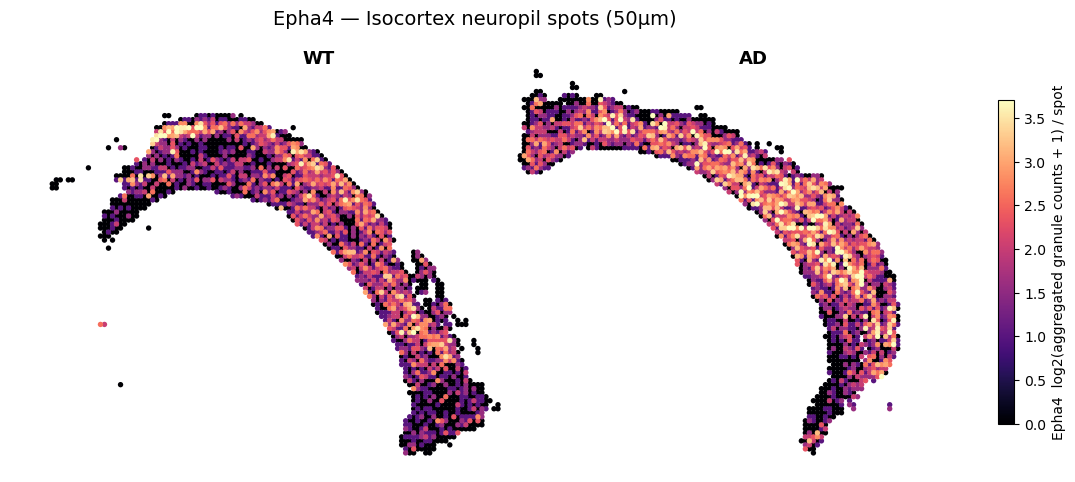

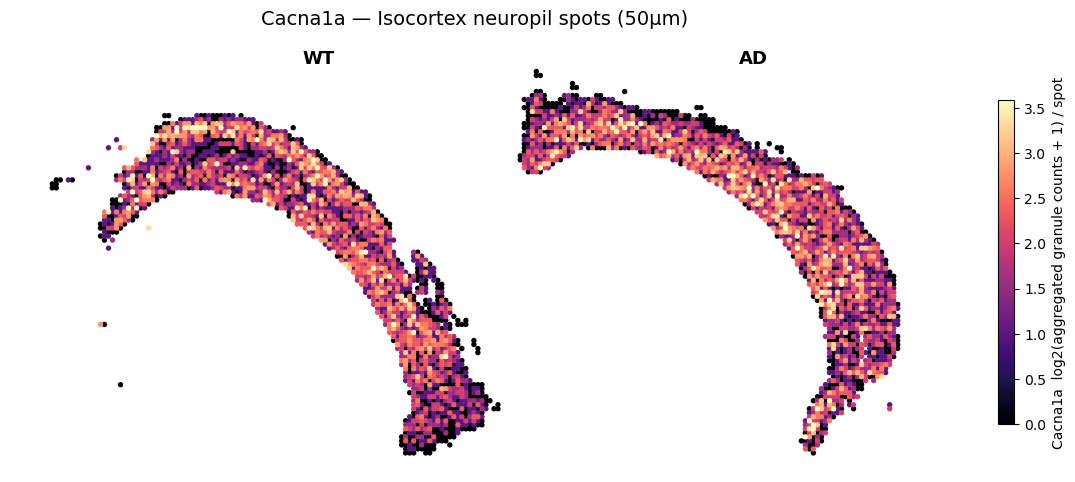

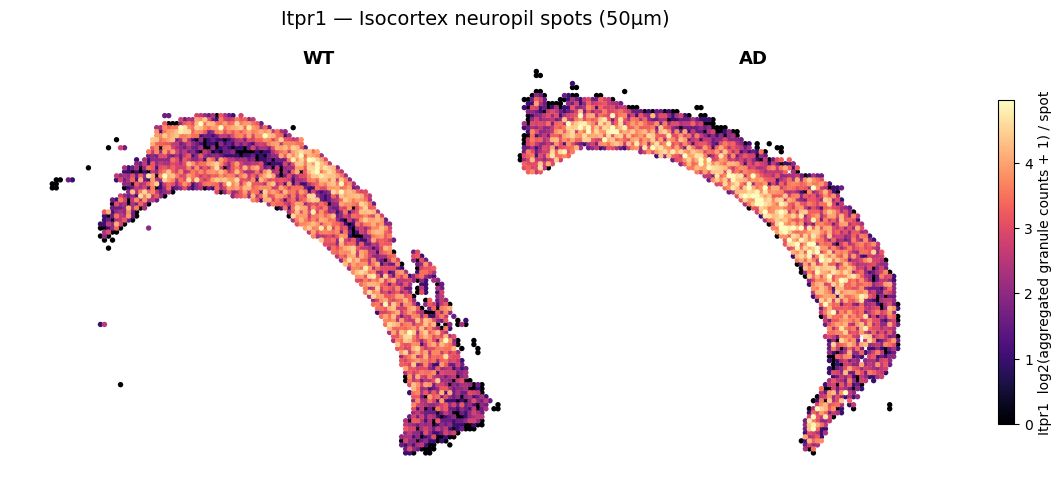

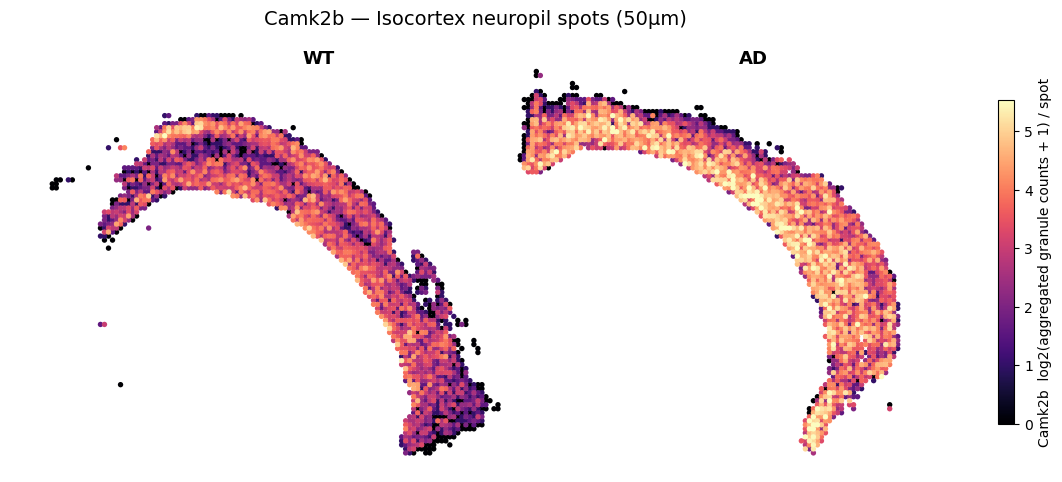

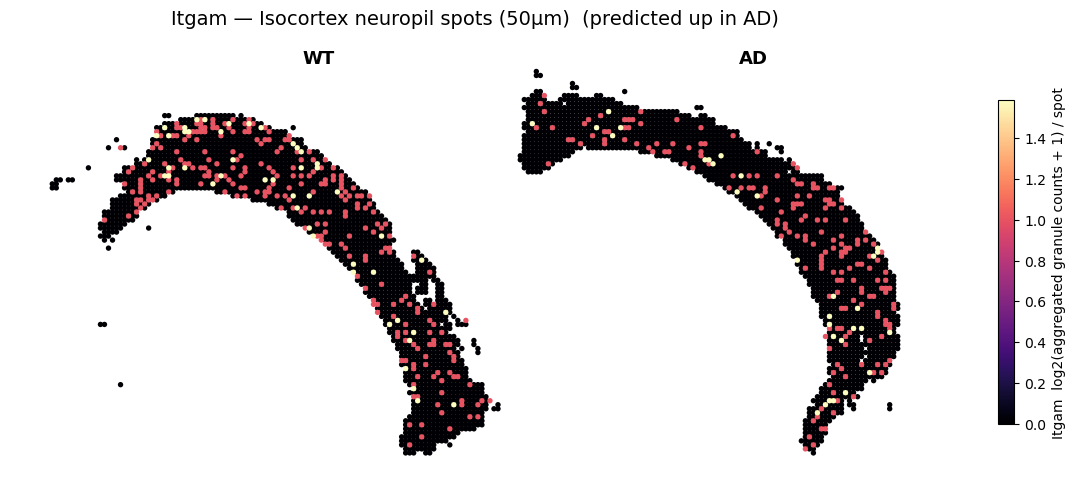

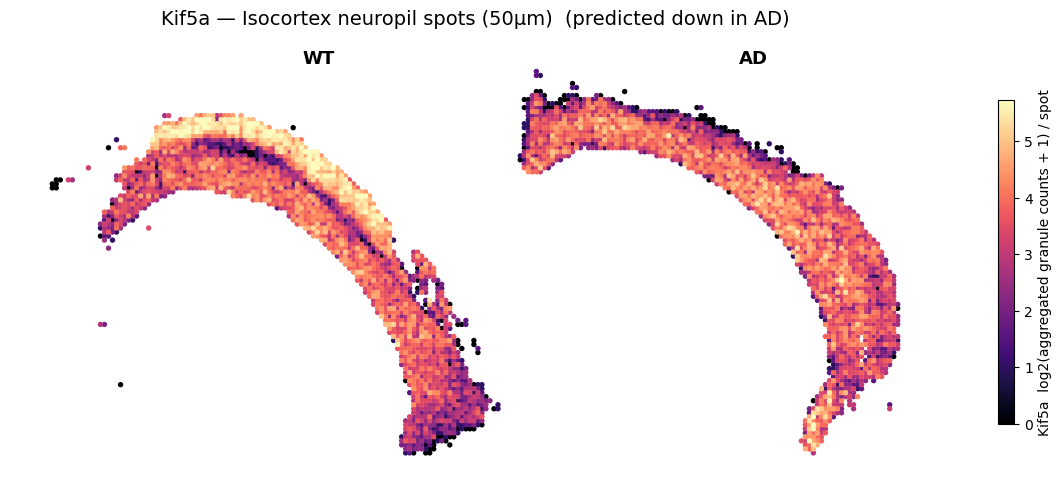

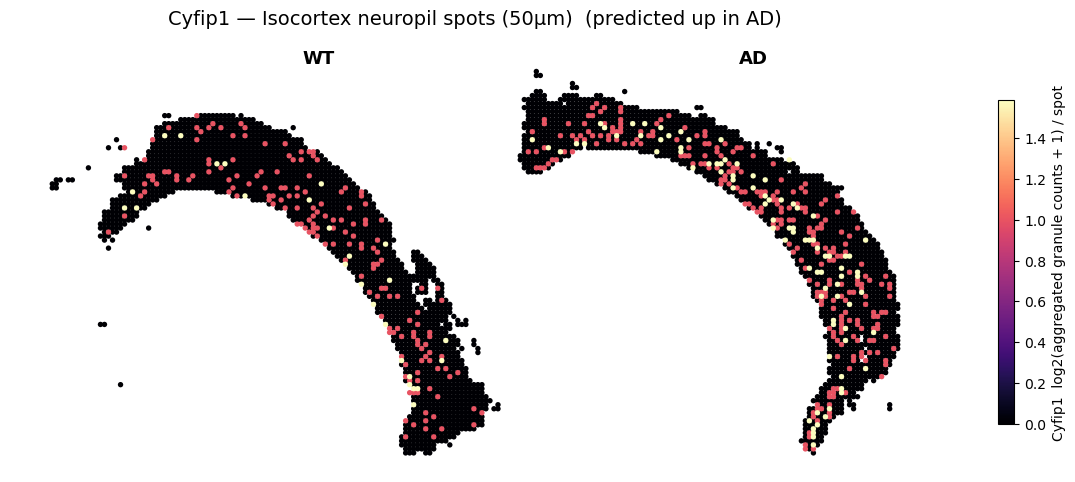

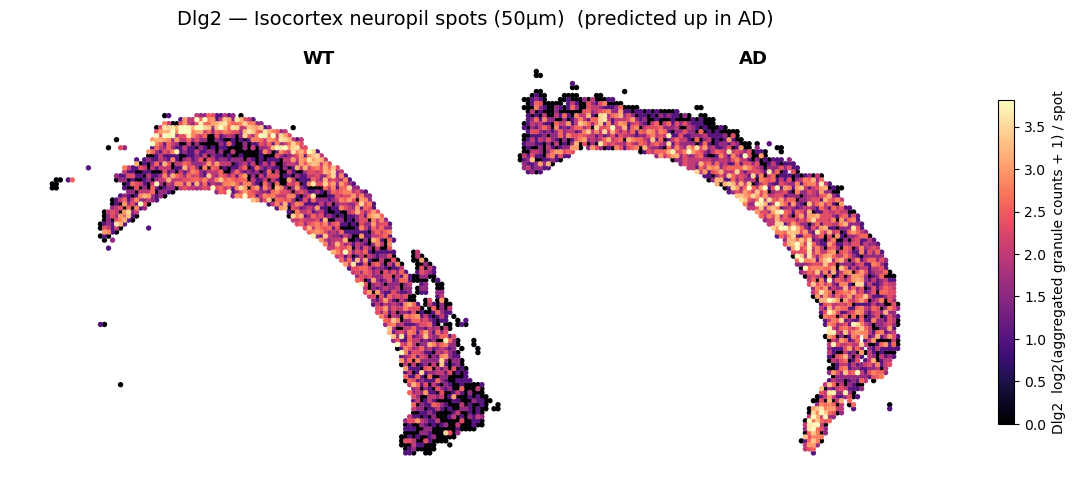

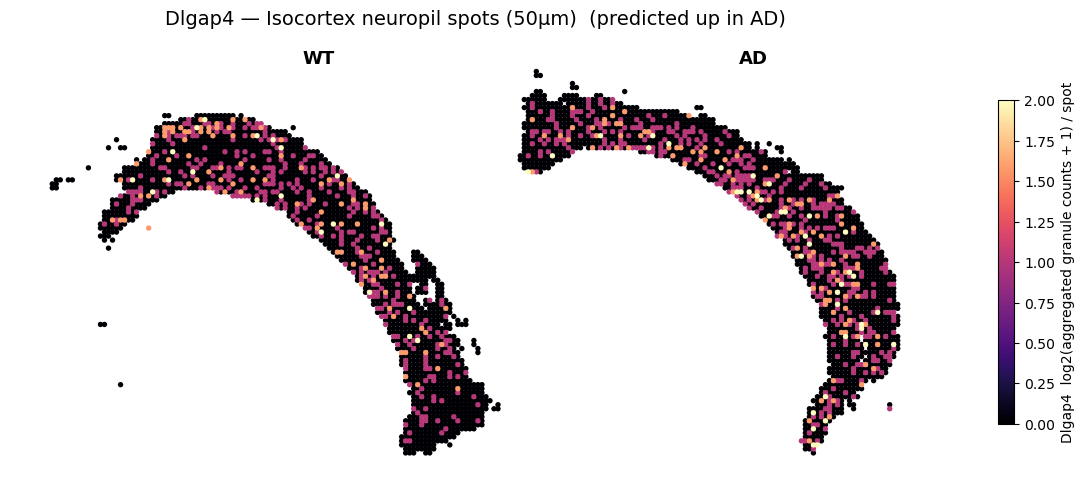

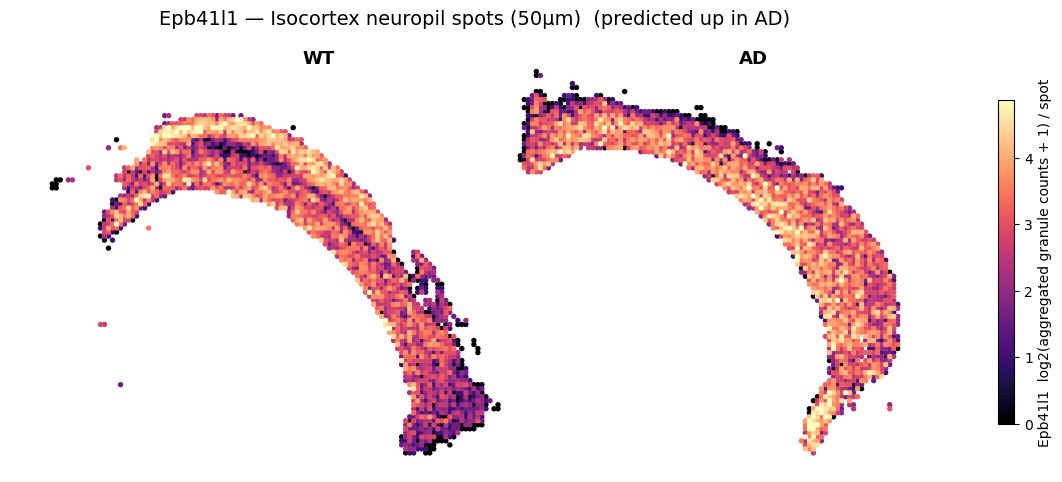

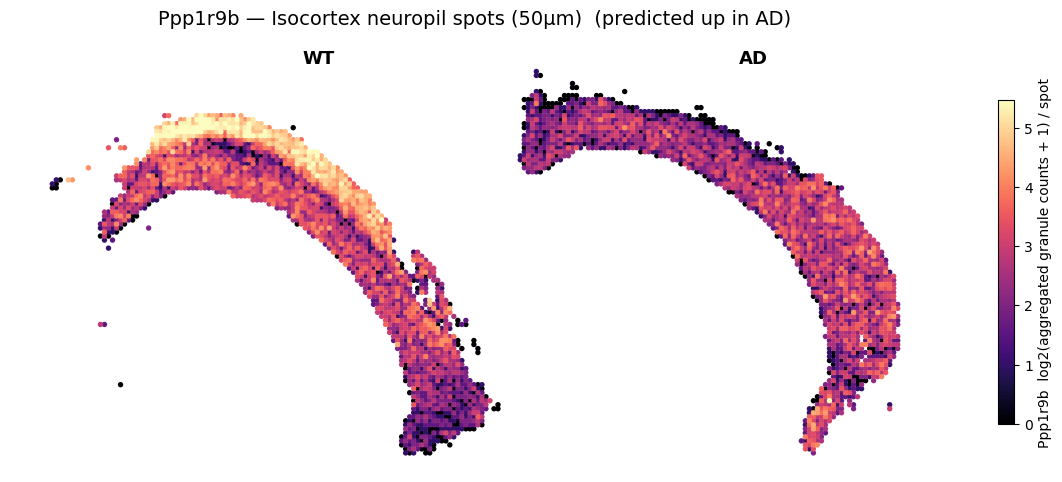

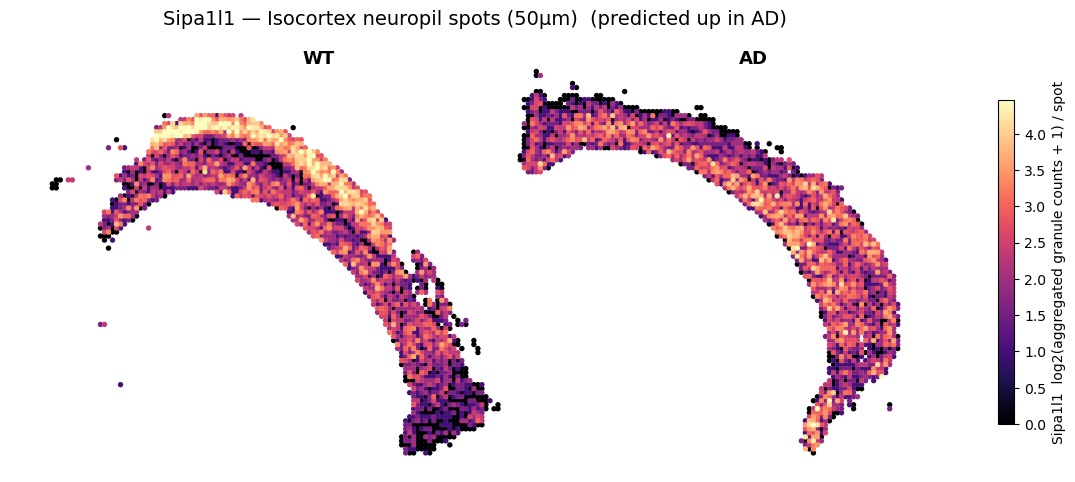

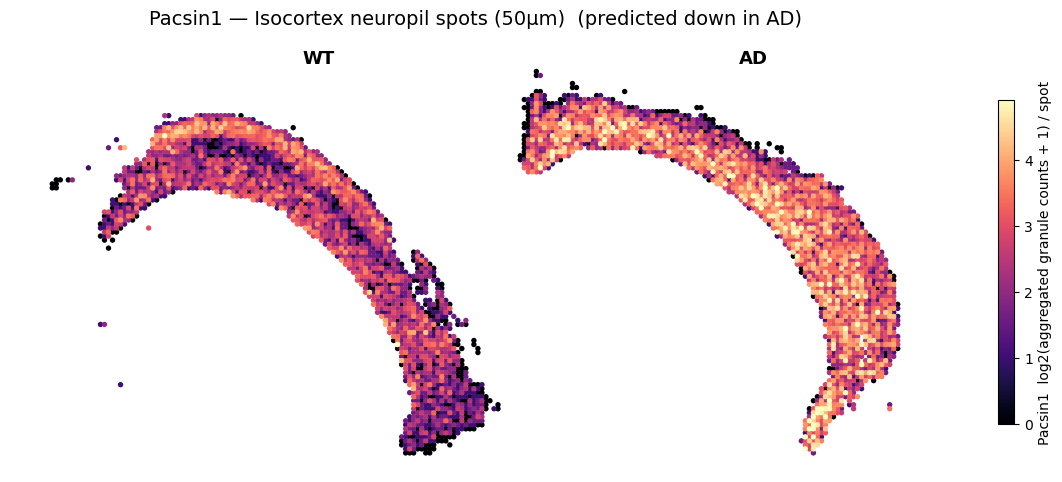


=== AD genes (AD_genes) -> /Users/chenyang/Desktop/mcDETECT/output/MERSCOPE_WT_AD_2_comparison/AD_genes_expression_Isocortex_50/ ===


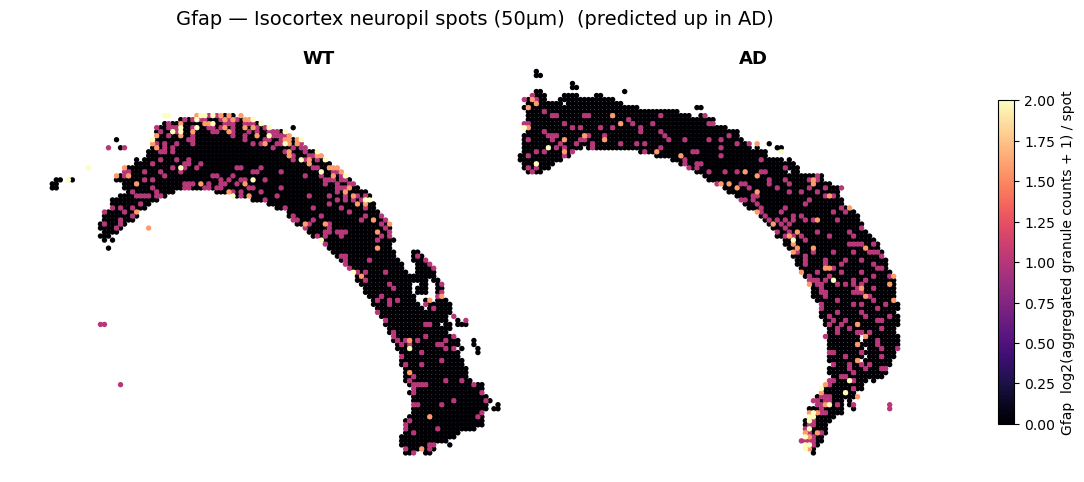

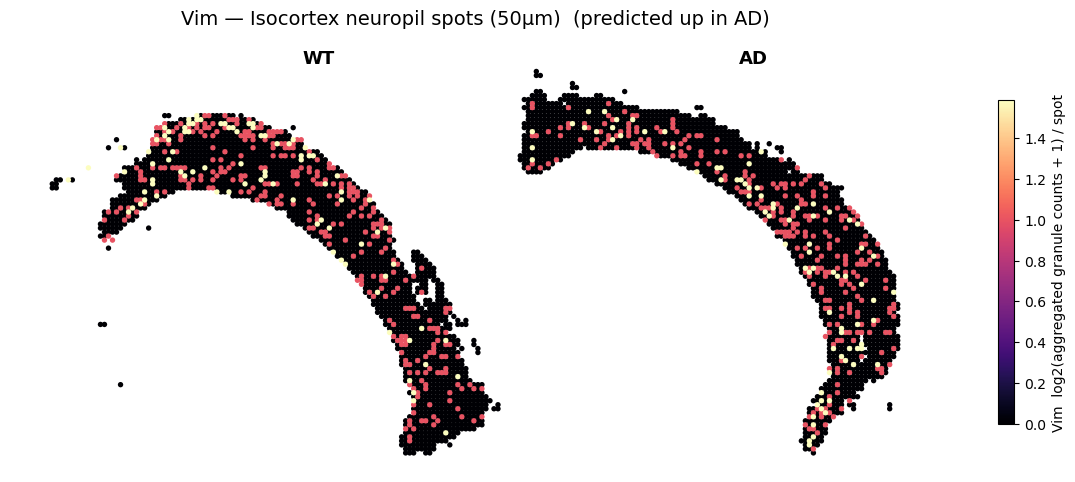

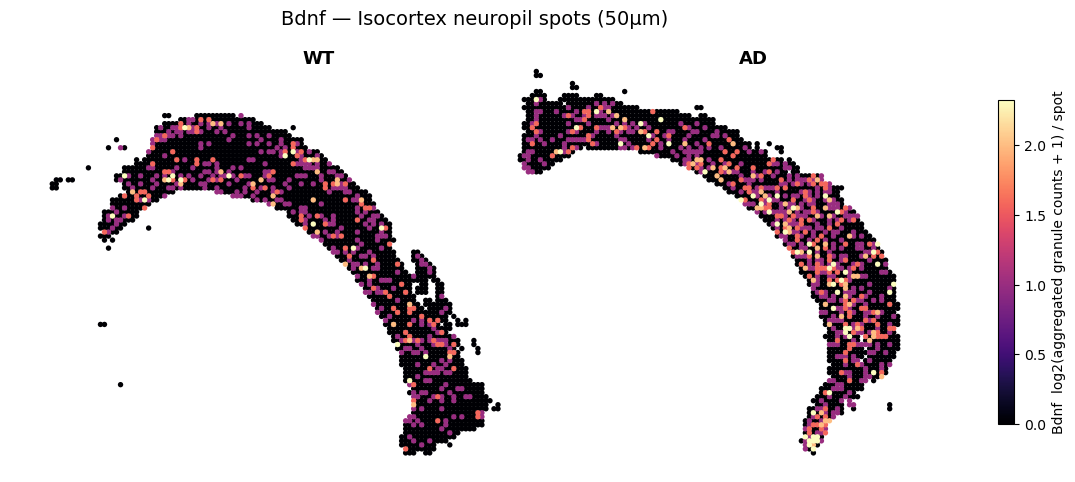

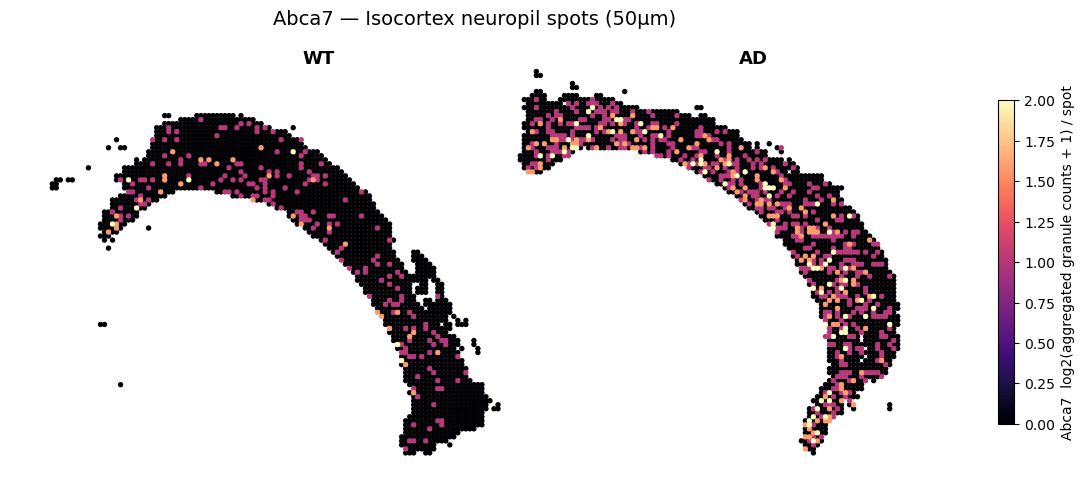

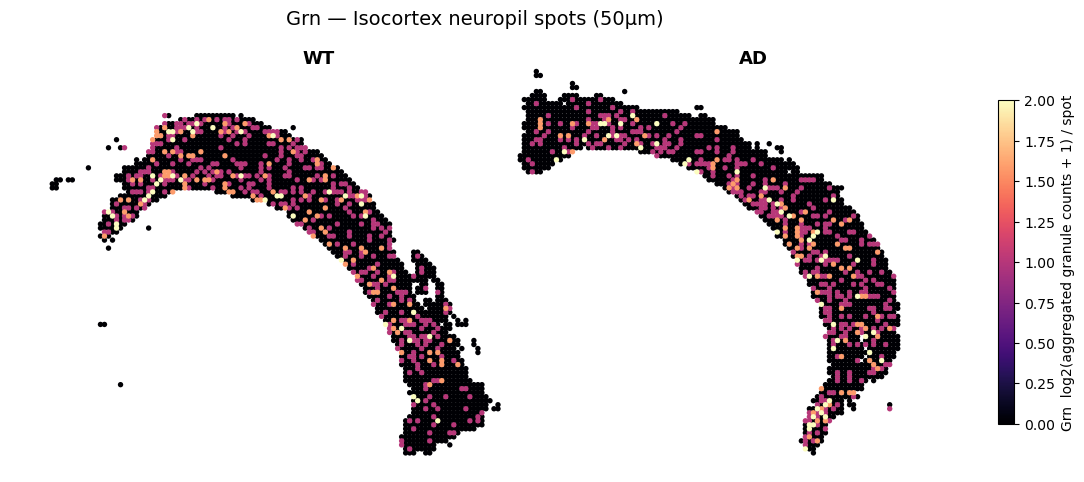

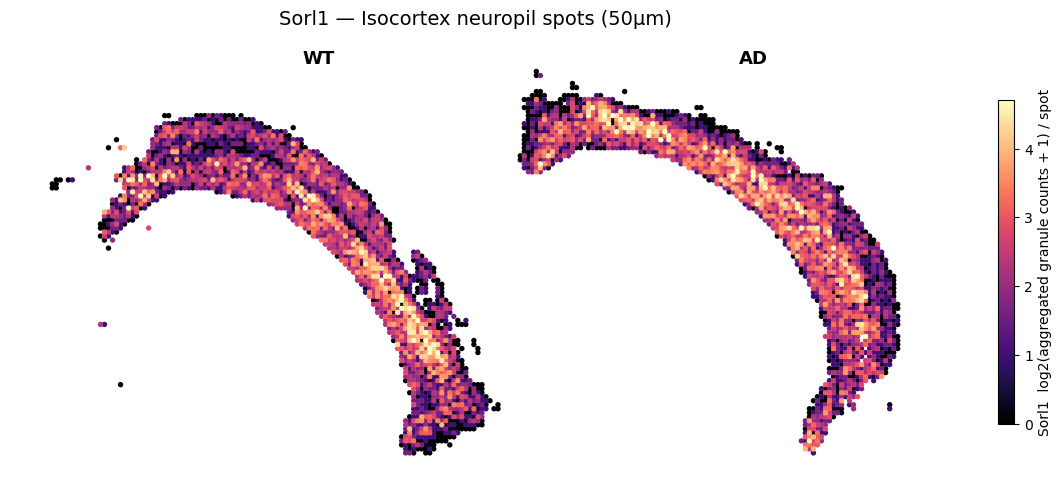

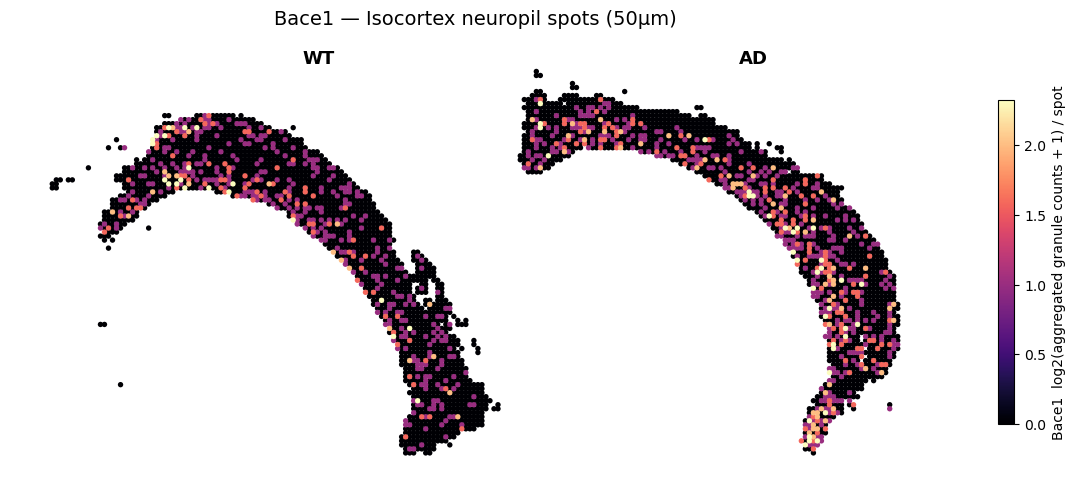

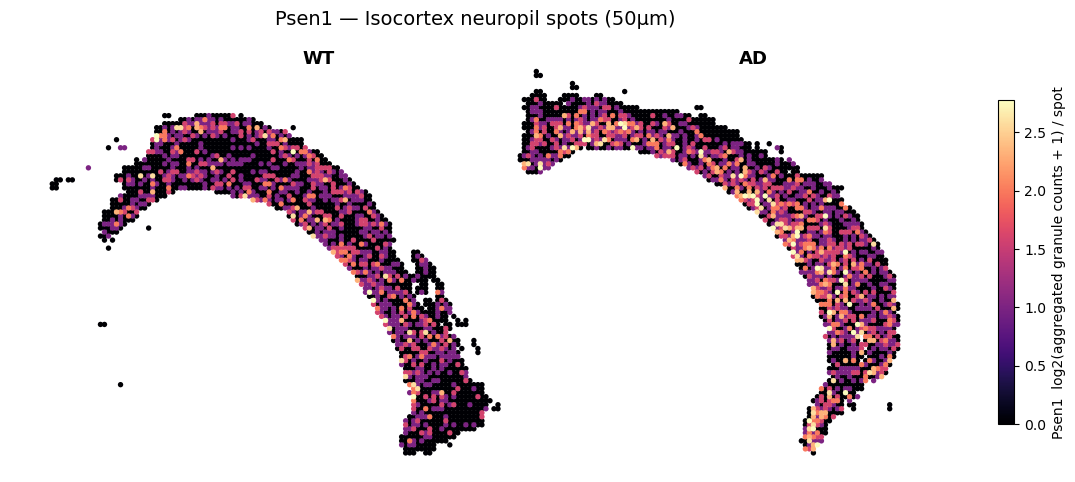

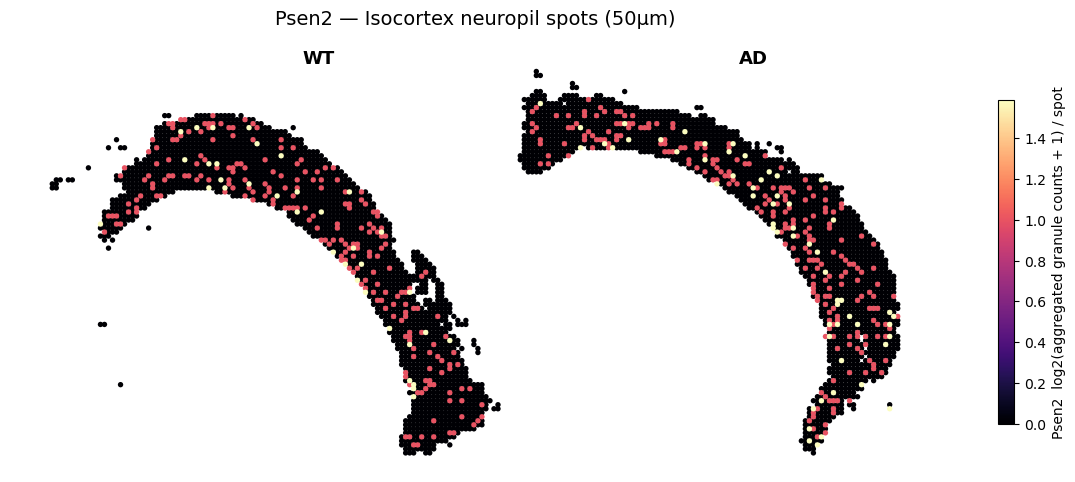

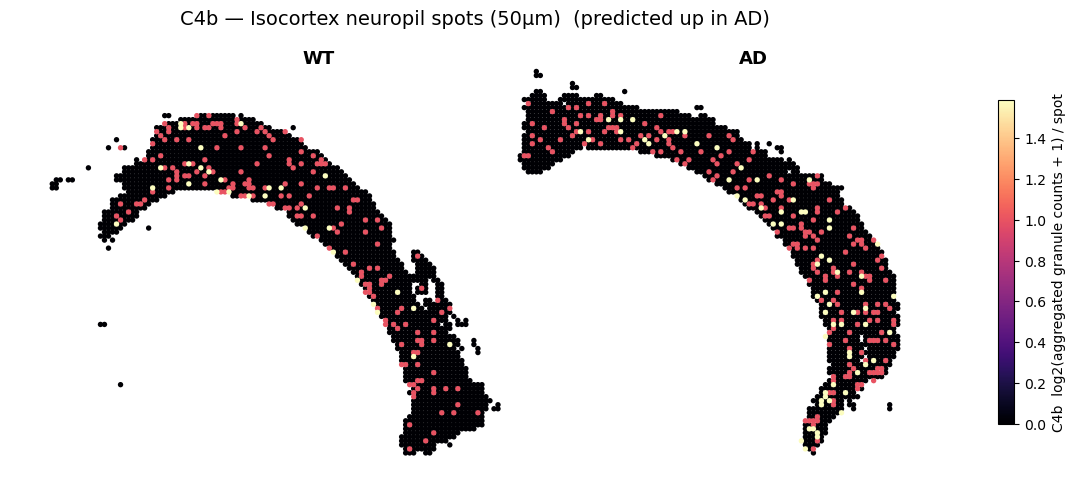

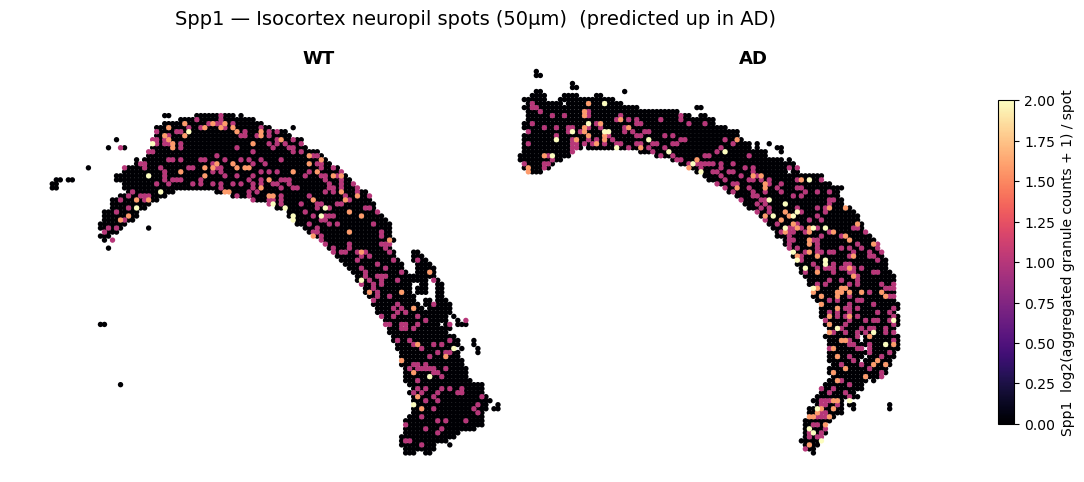

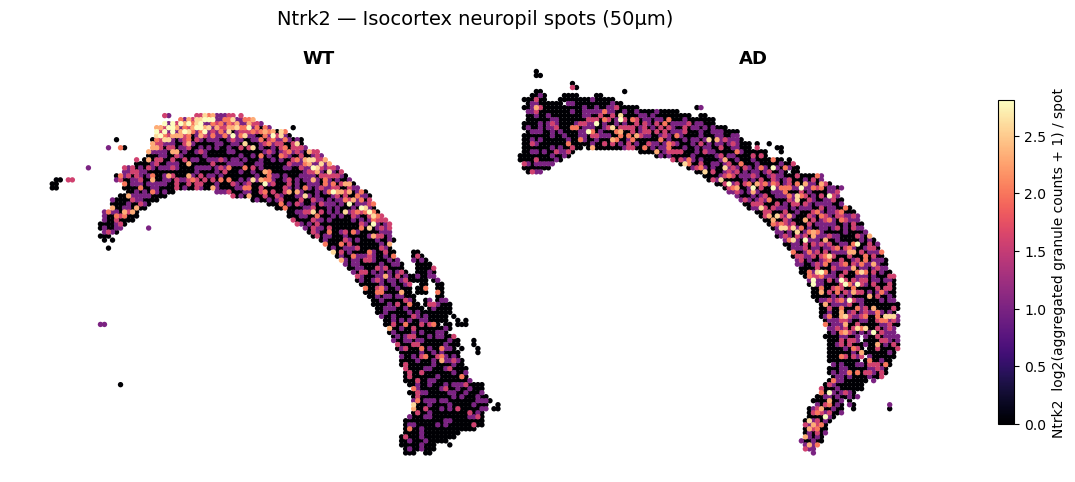

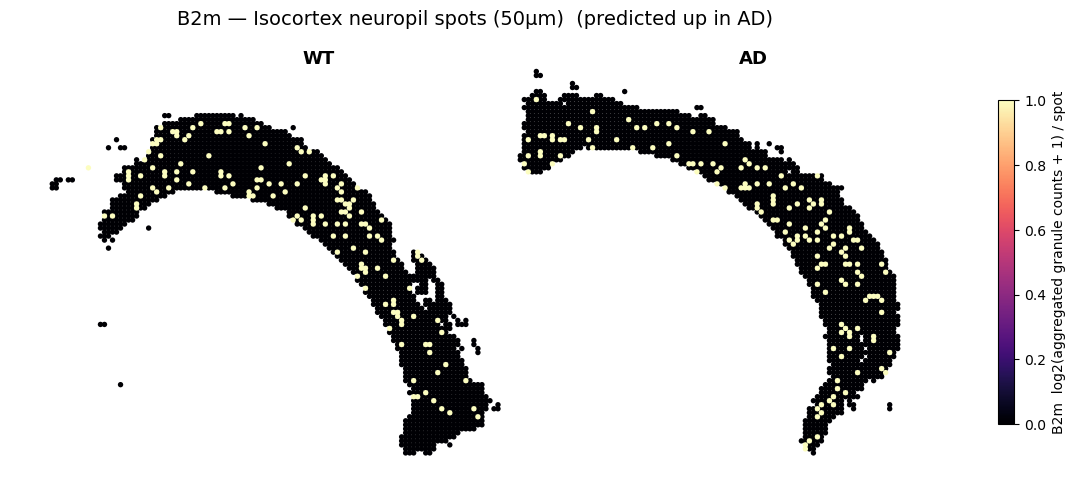

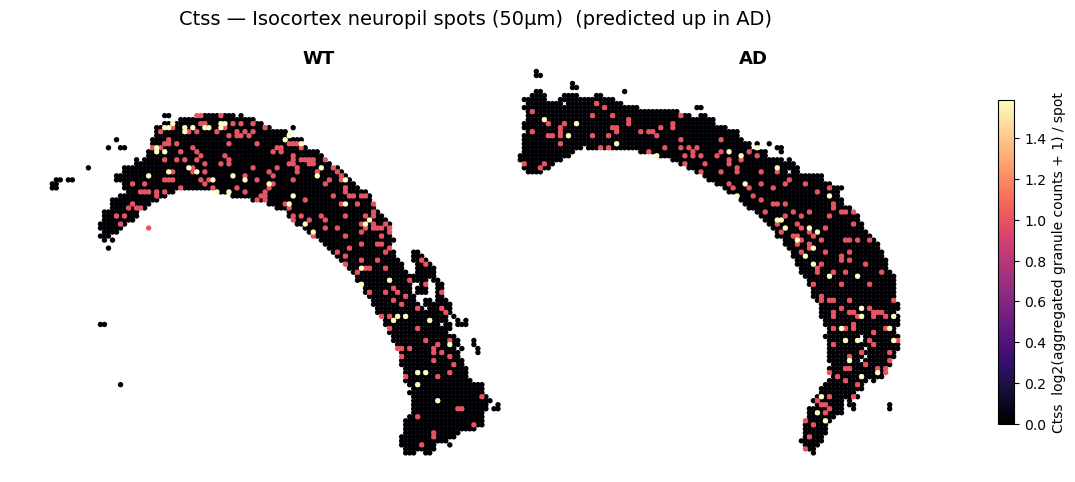

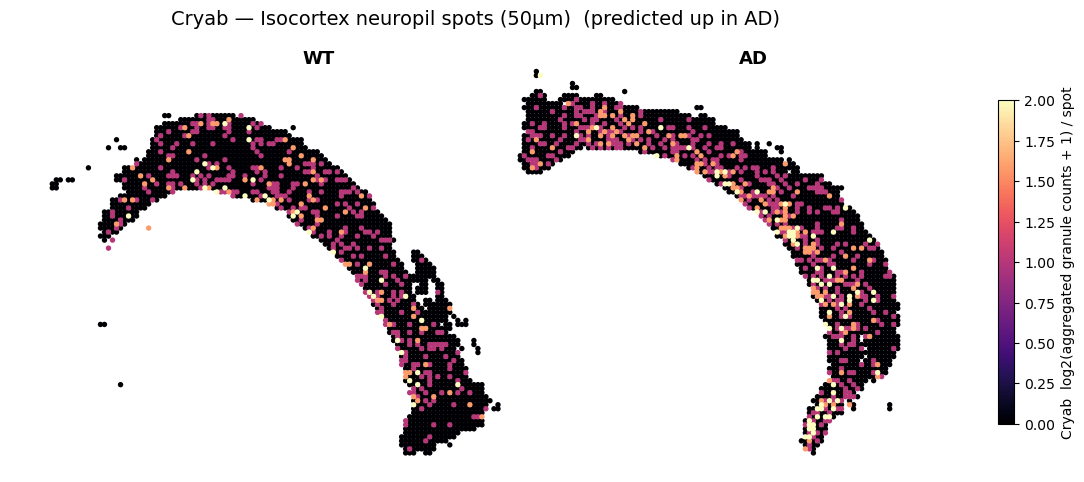

In [8]:
def plot_gene(gene, out_dir, save=True):
    direction = gene_direction.get(gene, "")
    # Aggregated granule expression per spot (sum of granule counts inside the spot),
    # log2-transformed as log2(counts + 1).
    vals = np.log2(combined[gene].to_numpy(dtype=float) + 1.0)
    vmax = np.percentile(vals, VMAX_PCT)
    vmax = float(vmax) if vmax > 0 else float(max(vals.max(), 1.0))

    fig, ax = plt.subplots(figsize=(15, 7))
    # Draw higher-expression spots last so they are not hidden.
    order = np.argsort(vals)
    sca = ax.scatter(
        combined["global_x"].to_numpy()[order],
        combined["global_y"].to_numpy()[order],
        c=vals[order], cmap=CMAP, s=DOT_SIZE, vmin=0, vmax=vmax,
        linewidths=0, marker="o",
    )
    cbar = fig.colorbar(sca, ax=ax, shrink=0.6)
    cbar.set_label(f"{gene}  log2(aggregated granule counts + 1) / spot")

    ax.text(wt_cx, y_top + GRID_LEN, "WT", ha="center", va="bottom", fontsize=13, fontweight="bold")
    ax.text(ad_cx, y_top + GRID_LEN, "AD", ha="center", va="bottom", fontsize=13, fontweight="bold")

    dir_title = f"  (predicted {direction} in AD)" if direction else ""
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{gene} — {ROI} neuropil spots ({GRID_LEN}µm){dir_title}", fontsize=14, pad=20)
    for spine in ax.spines.values():
        spine.set_visible(False)
    if save:
        suffix = f"_{direction}" if direction else ""
        fname = os.path.join(out_dir, f"expr_{gene}{suffix}.jpeg")
        fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()


for key, _, _, label in GENE_SET_SPECS:
    out_dir = OUTPUT_PATHS[key]
    print(f"\n=== {label} ({key}) -> {out_dir} ===")
    for g in genes_by_set[key]:
        plot_gene(g, out_dir)

## 6. Grouped violin plots: WT vs AD per gene

For each gene set, a grouped (split) violin plot of the per-spot **log2(aggregated granule counts + 1)** for every selected gene. x-axis = genes (predicted AD direction annotated), y-axis = log2 counts, hue = WT vs AD. Saved into the matching set folder.

Saved /Users/chenyang/Desktop/mcDETECT/output/MERSCOPE_WT_AD_2_comparison/pathway_p1_expression_Isocortex_50/violin_pathway_p1_WT_vs_AD.jpeg


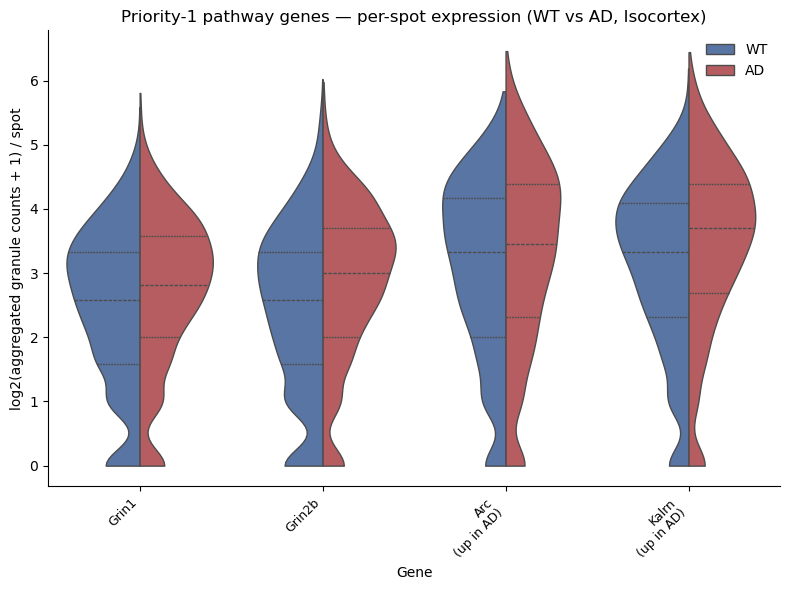

Saved /Users/chenyang/Desktop/mcDETECT/output/MERSCOPE_WT_AD_2_comparison/pathway_p2_expression_Isocortex_50/violin_pathway_p2_WT_vs_AD.jpeg


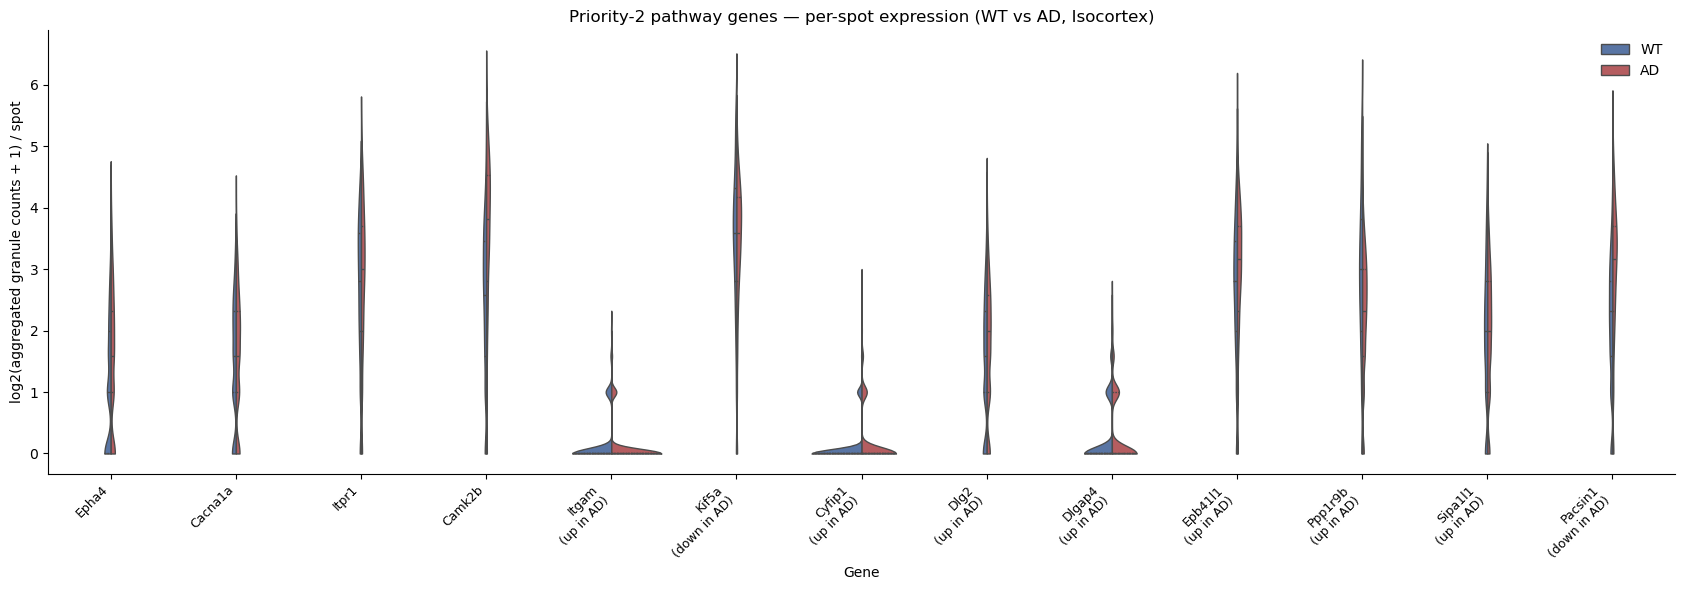

Saved /Users/chenyang/Desktop/mcDETECT/output/MERSCOPE_WT_AD_2_comparison/AD_genes_expression_Isocortex_50/violin_AD_genes_WT_vs_AD.jpeg


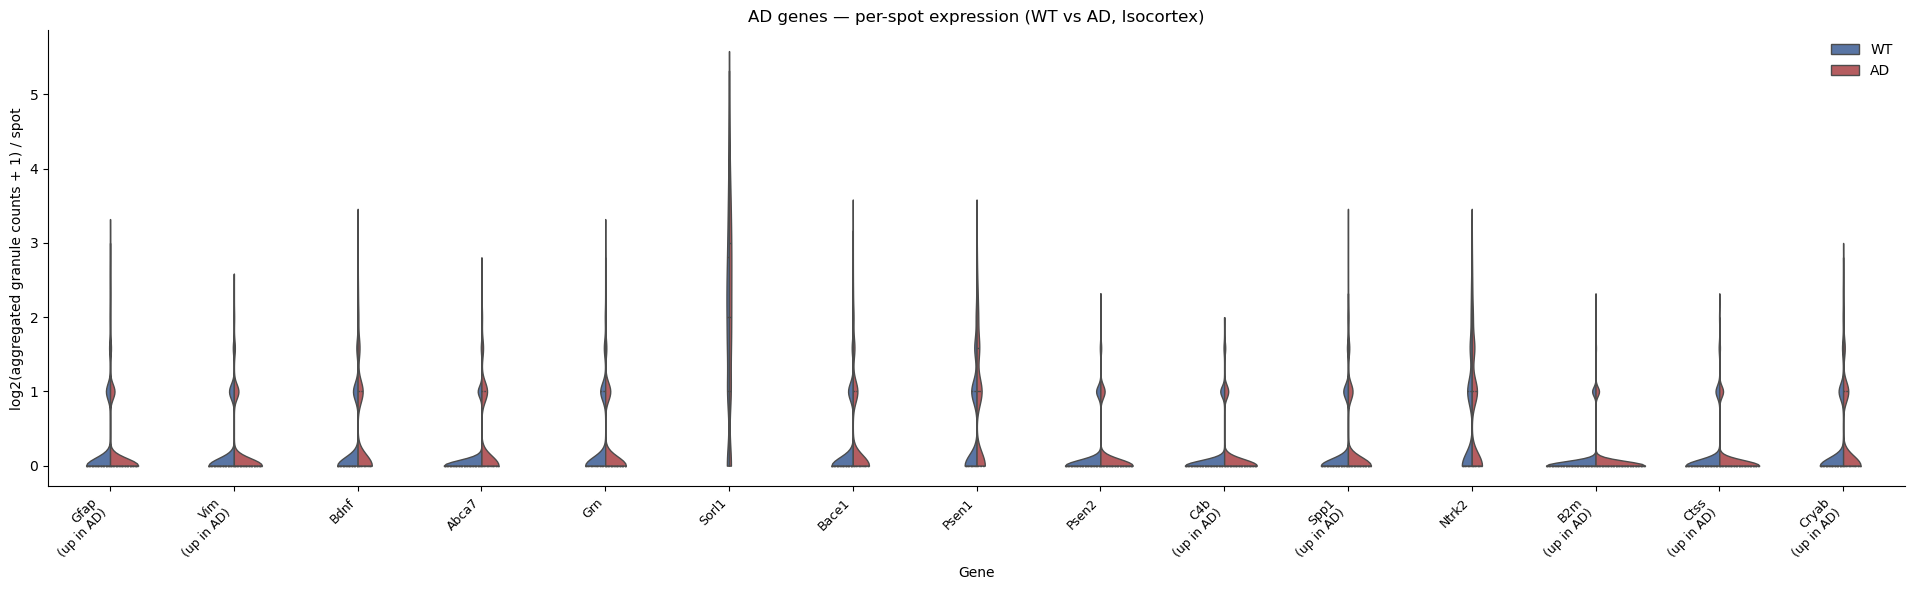

In [9]:
def violin_set(key, label):
    genes_k = genes_by_set[key]
    if not genes_k:
        print(f"{label} ({key}): no genes present on panel; skipping violin.")
        return

    long_df = combined[["sample"] + genes_k].melt(
        id_vars="sample", value_vars=genes_k, var_name="gene", value_name="counts"
    )
    long_df["log2_counts"] = np.log2(long_df["counts"].to_numpy(dtype=float) + 1.0)

    def gene_label(g):
        d = gene_direction.get(g, "")
        return f"{g}\n({d} in AD)" if d else g

    fig, ax = plt.subplots(figsize=(max(8, 1.15 * len(genes_k) + 2), 6))
    sns.violinplot(
        data=long_df, x="gene", y="log2_counts", hue="sample",
        order=genes_k, hue_order=["WT", "AD"], split=True, inner="quartile",
        palette={"WT": "#4C72B0", "AD": "#C44E52"}, cut=0, linewidth=1, ax=ax,
    )
    ax.set_xticks(range(len(genes_k)))
    ax.set_xticklabels([gene_label(g) for g in genes_k], rotation=45, ha="right", fontsize=9)
    ax.set_xlabel("Gene")
    ax.set_ylabel("log2(aggregated granule counts + 1) / spot")
    ax.set_title(f"{label} — per-spot expression (WT vs AD, {ROI})")
    ax.legend(title="", frameon=False, loc="upper right")
    sns.despine(ax=ax)
    fig.tight_layout()
    out = os.path.join(OUTPUT_PATHS[key], f"violin_{key}_WT_vs_AD.jpeg")
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved {out}")
    plt.show()


for key, _, _, label in GENE_SET_SPECS:
    violin_set(key, label)